In [1]:
# %matplotlib widget
import numpy as np
from sim_library.constants import k_eff, dR, m, kb, omega_eg
from scipy.constants import hbar, pi
import matplotlib.pyplot as plt
from pathlib import Path
from sim_library.simulation import simulate_pulses_single_atom, simulate_pulses_single_atom_analyt, simulate_pulses_p_dist, simulate_alg_cooling, simulate_alg_cooling_custom
from sim_library.sequences import RR3_gate, PulseSequence, UpPulse, DownPulse, FreeEvolution, gen_MDFEup_seq, gen_MDFEdown_seq, RR3_adjMDFE_500kHz
from sim_library.plotting import plot_state_trajectories, plot_bloch, plot_hist, save_gif, plot_coolingcycles_22, fit_gaussian, fit_gaussian_custom, display_table_compare, plot_bloch_multi
from sim_library.data_io import load_p_dists

[0.0098281  0.04908682 0.08813411 0.12681305]
0.03925872834333184


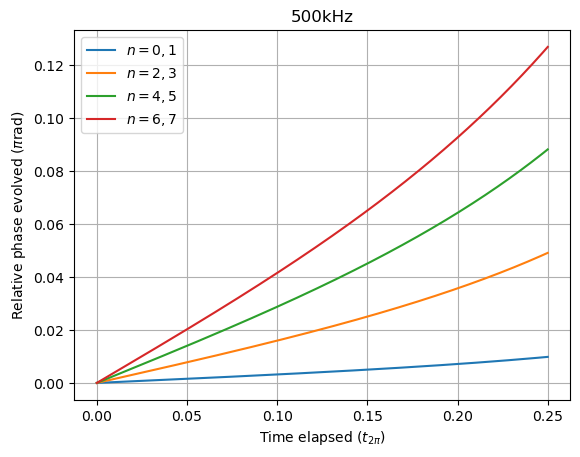

In [23]:
### Numerical

# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1000

indices = [8,10,12,14]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)


# Set doppler shift
atom_veloc = 0.0 # Stationary

pulse_seq1 = PulseSequence()

pulse1 = UpPulse(laser_det=np.full(n_steps,0),phase=np.full(n_steps, pi/2), rabi_freq=np.full(n_steps,rabi_freq), duration=rabi_time/4)

pulse_seq1.add_pulses([pulse1])


for i in range(len(indices)):
    initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
    initial_state[indices[i]] = 1
    initial_state[indices[i]+1] = 0
    initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise
    

    wave_func, times = simulate_pulses_single_atom(pulse_seq=pulse_seq1, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)

    if i == 0:
        wave_funcs = np.zeros((len(indices),len(times),2), dtype=np.complex128)

    wave_funcs[i,:,:] = wave_func[:,indices[i]:indices[i]+2]


angles = (np.angle(wave_funcs[:,:,1]) - np.angle(wave_funcs[:,:,0]))

angles = np.unwrap(angles, axis=1)

fig, ax = plt.subplots()
ax.plot(times/(rabi_time),angles.transpose()/pi)
# ax.set_yticks([0,0.02,0.04,0.06,0.08,0.1,0.12],[r'0.00', r'0.02$\pi$', r'0.04$\pi$', r'0.06$\pi$', r'0.08$\pi$', r'0.1$\pi$', r'0.12$\pi$'])
# ax.set_ylim(-0.005,0.12)
ax.grid()
ax.set_ylabel(r'Relative phase evolved ($\pi$rad)')
ax.set_xlabel(r'Time elapsed ($t_{2\pi}$)')
ax.legend([r'$n=0,1$',r'$n=2,3$',r'$n=4,5$',r'$n=6,7$'])
ax.set_title('500kHz')
# plt.ylim(0,2.1)
# plt.xlim(0,(rabi_time/2)*1.1)

print(angles[:,-1]/pi)
print((angles[1,-1]-angles[0,-1])/pi)




# display_table_compare(basis=basis, init_state=wave_func[0,:], final_state=wave_func[-1,:])
# plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1], show=True)

In [35]:
### Analytical
# def bsphase_nearres(n, omega_R):
#     return (2*n+1)*dR/omega_R

# def bsphase(n, omega_R):
#     squarrt = np.sqrt(omega_R**2+((2*n+1)*dR)**2)
#     return np.arctan(np.tan(pi*squarrt/4/omega_R)*(2*n+1)*dR/squarrt)

def bsphase_nearres(detuning, omega_R):
    return detuning/omega_R

def bsphase(detuning, omega_R):
    squarrt = np.sqrt((omega_R**2)+(detuning**2))
    return np.arctan(np.tan(pi*squarrt/4/omega_R)*detuning/squarrt)

Analytical: [0.0098281  0.04908682 0.08813411 0.12681305]
Numerical: [0.0098281  0.04908682 0.08813411 0.12681305]
Linear approx: [0.00982854 0.04914272 0.0884569  0.12777108]


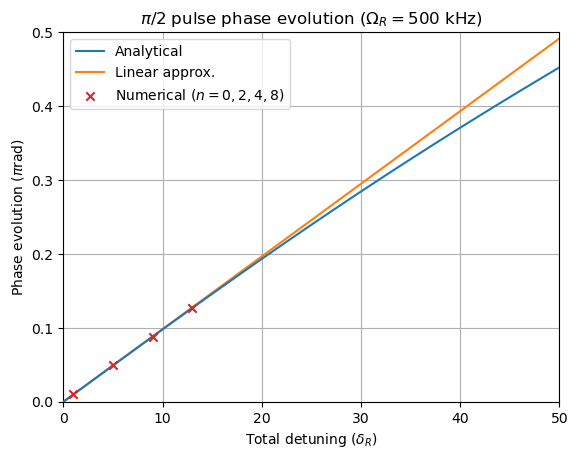

In [45]:
# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

state_ns = np.array([0,2,4,6])
print('Analytical:',bsphase((2*state_ns+1)*dR,omega_R=rabi_freq)/pi)
print('Numerical:', angles[:,-1]/pi)
print('Linear approx:', bsphase_nearres((2*state_ns+1)*dR,omega_R=rabi_freq)/pi)

dets = np.linspace(0,50*dR,100)

phases_appr = bsphase_nearres(dets, omega_R=rabi_freq)/pi
phases = bsphase(dets, omega_R=rabi_freq)/pi

fig, ax  = plt.subplots()
ax.plot(dets/dR, phases, zorder=10)
ax.plot(dets/dR, phases_appr)
ax.scatter((2*state_ns+1), angles[:,-1]/pi, c='tab:red', zorder=20, marker='x')
ax.set_title(r'$\pi/2$ pulse phase evolution ($\Omega_R=500$ kHz)')
ax.grid()
ax.set_ylim(0,0.5)
ax.set_xlim(0,50)
ax.set_ylabel(r'Phase evolution ($\pi$rad)')
ax.set_xlabel(r'Total detuning ($\delta_R$)')
ax.legend([r'Analytical', r'Linear approx.', 'Numerical ($n=0,2,4,8$)'])



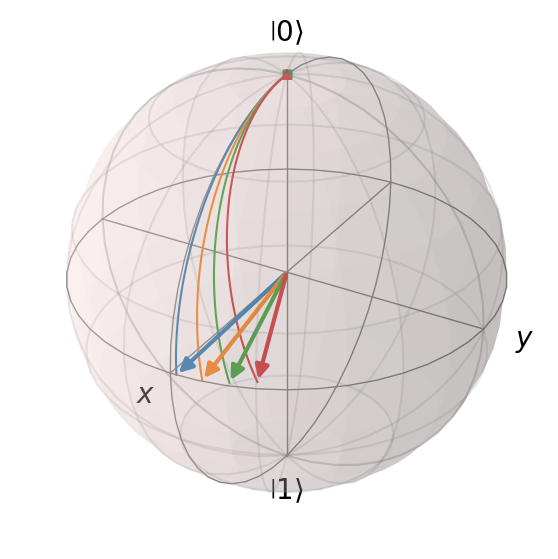

In [5]:
# %matplotlib widget
b, fig = plot_bloch_multi(wave_func=wave_funcs, show=True)
# fig


[1.24453355e+00 1.18912983e+00 1.14740545e+00 1.11611102e+00
 1.09252151e+00 1.07457298e+00 1.06076663e+00 5.00267281e-02
 4.15800771e-02 3.48670165e-02 2.94786243e-02 2.51130417e-02
 2.15451121e-02 1.86051653e-02 1.61640738e-02 1.41226299e-02
 1.24039215e-02 1.09478074e-02 9.70687526e-03 8.64345759e-03
 7.72740855e-03 6.93443373e-03 6.24482483e-03 5.64249361e-03
 5.11422876e-03 4.64912005e-03 4.23810914e-03 3.87363678e-03
 3.54936408e-03 3.25995083e-03 3.00087832e-03 2.76830688e-03
 2.55896069e-03 2.37003430e-03 2.19911621e-03 2.04412633e-03
 1.90326436e-03 1.77496717e-03 1.65787333e-03 1.55079361e-03
 1.45268619e-03 1.36263597e-03 1.27983696e-03 1.20357754e-03
 1.13322785e-03 1.06822909e-03 1.00808441e-03 9.52351042e-04
 9.00633610e-04 8.52578333e-04 8.07868029e-04 7.66217789e-04
 7.27371225e-04 6.91097209e-04 6.57187020e-04 6.25451868e-04
 5.95720706e-04 5.67838330e-04 5.41663691e-04 5.17068422e-04
 4.93935527e-04 4.72158229e-04 4.51638944e-04 4.32288378e-04
 4.14024711e-04 3.967728

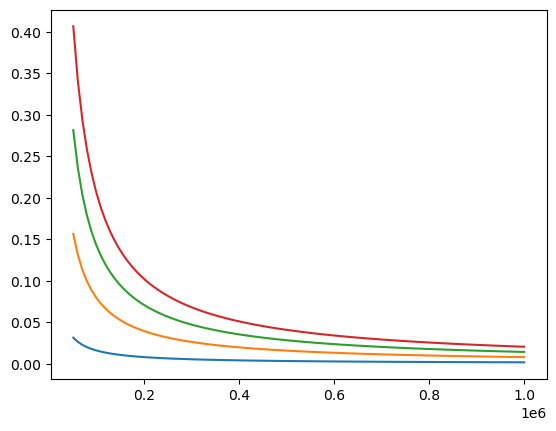

In [61]:
# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

state_ns = np.array([0,2,4,6])

# rabis = 2*pi*np.logspace(5,6,1000, base=10)
rabis = 2*pi*np.linspace(0.5e5, 1e6, 100)

phases = np.zeros((len(state_ns), len(rabis)))
phases_lin = np.zeros((len(state_ns), len(rabis)))
                  
for i in range(len(state_ns)):
    phases[i,:] = bsphase((2*state_ns[i]+1)*dR, omega_R=rabis)/pi
    phases_lin[i,:] = bsphase_nearres((2*state_ns[i]+1)*dR, omega_R=rabis)/pi

residuals = phases_lin - phases



fig, ax  = plt.subplots()
# ax.semilogx(rabis/(2*pi), residuals.transpose()/pi, zorder=10)
ax.plot(rabis/(2*pi), phases_lin.transpose()/pi, zorder=10)


print(residuals[3,:])
# ax.set_title(r'$\pi/2$ pulse phase evolution ($\Omega_R=500$ kHz)')
# ax.grid()
# ax.set_ylim(0,0.5)
# ax.set_xlim(0,50)
# ax.set_ylabel(r'Phase evolution ($\pi$rad)')
# ax.set_xlabel(r'Total detuning ($\delta_R$)')
# ax.legend([r'Analytical', r'Linear approx.', 'Numerical ($n=0,2,4,8$)'])

